ЗАГРУЗКА ДАННЫХ...
Файл успешно загружен!
Всего записей: 485
📑 Столбцов: 36

Данные готовы к анализу
----------------------------------------------------------------------

ЧАСТЬ 1: Доля курильщиков
----------------------------------------------------------------------

📊 ТАБЛИЦА СОПРЯЖЕННОСТИ:


Онкология,0,1
Курение,,
да,65,90
нет,157,173



📈 РЕЗУЛЬТАТЫ СТАТИСТИЧЕСКОГО ТЕСТА:


,Параметр,Значение
0,χ² (хи-квадрат),1.1340
1,p-value,0.286921
2,Степени свободы,1



❌ ВЫВОД: Связь НЕ является статистически значимой (p ≥ 0.05)

📊 ПРОЦЕНТНОЕ РАСПРЕДЕЛЕНИЕ:


,Без онкологии (%),Онкология (%)
Курение,,
да,41.9%,58.1%
нет,47.6%,52.4%


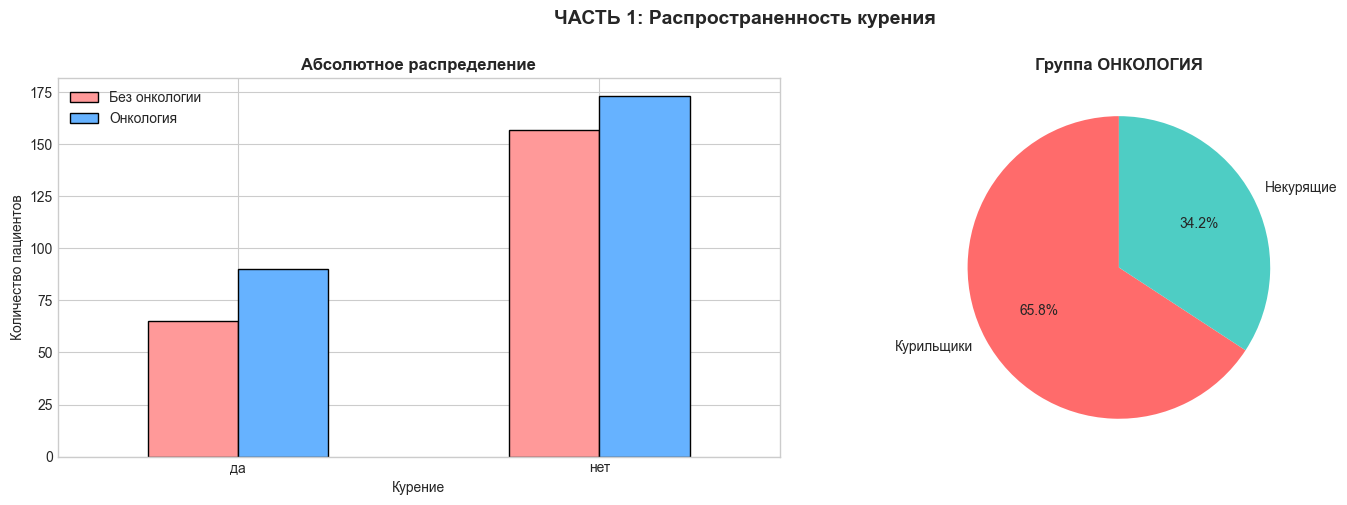


ЧАСТЬ 2: Размер очага
----------------------------------------------------------------------

📊 ОПИСАТЕЛЬНАЯ СТАТИСТИКА:
--------------------------------------------------
    Группа   N Среднее (мм) Медиана (мм) Стд. отклонение Min (мм) Max (мм)
Курильщики 155        19.73        19.00            7.01     8.00    30.00
 Некурящие 330        19.30        18.50            6.74     8.00    30.00
--------------------------------------------------

📈 Разница средних: 0.43 мм (+2.2%)

📈 РЕЗУЛЬТАТЫ СРАВНЕНИЯ ГРУПП:
--------------------------------------------------
              Тест Статистика  p-value              Значимость
U-тест Манна-Уитни 26403.0000 0.564622 ❌ Не значимо (p ≥ 0.05)
--------------------------------------------------


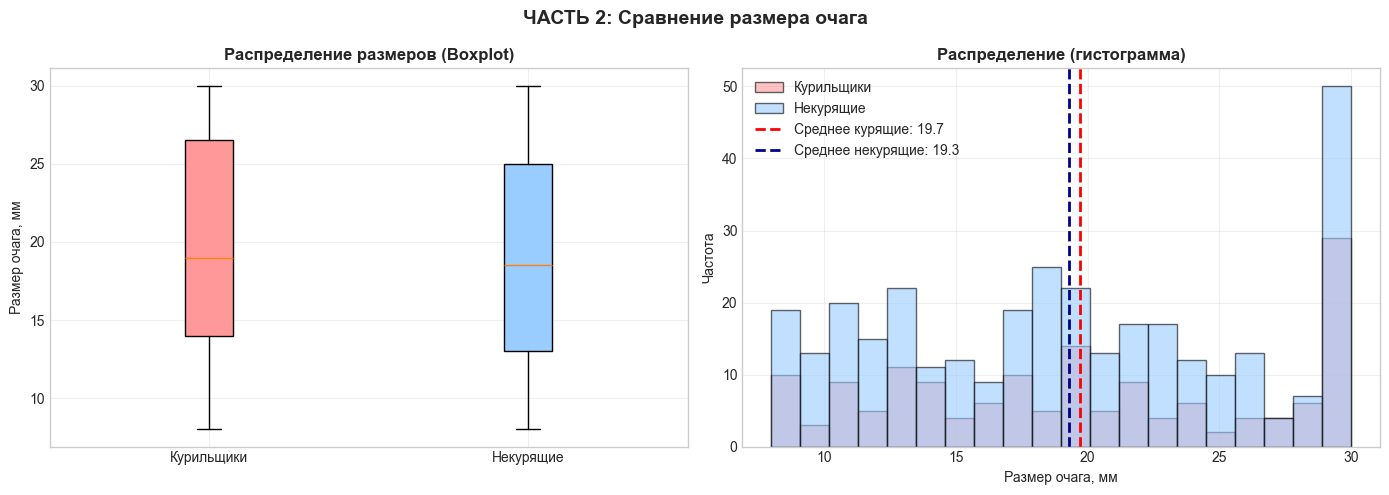


ЧАСТЬ 3: Отношение шансов (OR)
----------------------------------------------------------------------

📊 ТАБЛИЦА 2×2:
--------------------------------------------------
            Онкология (1)  Без онкологии (0)  Всего
Курильщики             90                 65    155
Некурящие             173                157    330
Всего                 263                222    485
--------------------------------------------------

РЕЗУЛЬТАТЫ РАСЧЕТА ОТНОШЕНИЯ ШАНСОВ:


,Показатель,Значение
0,Odds Ratio (OR),1.2566
1,95% ДИ (нижняя граница),0.8548
2,95% ДИ (верхняя граница),1.8472
3,ln(OR),0.2284
4,Стат. значимость,Не значимо



💡 ИНТЕРПРЕТАЦИЯ:
   📈 Курение УВЕЛИЧИВАЕТ шансы развития онкологии в 1.26 раз
   Эффект НЕ значим (95% ДИ включает 1)


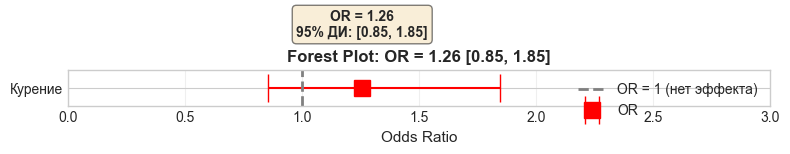


🔬 ЧАСТЬ 4: Взаимодействие с возрастом
----------------------------------------------------------------------

📊 СРЕДНИЙ РАЗМЕР ОЧАГА ПО ВОЗРАСТНЫМ ГРУППАМ:
--------------------------------------------------
                  Сред. размер, мм             Онк/Неонк
                              mean   std count      mean
Курение age_group                                       
да      <40                  18.69  7.11    29      0.24
        40-50                16.00  4.94    11      0.45
        50-60                20.11  6.97    44      0.70
        60-70                20.04  7.23    47      0.57
        >70                  21.38  7.08    24      0.83
нет     <40                  17.56  5.86    32      0.12
        40-50                18.57  6.30    42      0.33
        50-60                19.18  6.70    66      0.65
        60-70                18.94  6.77   122      0.54
        >70                  21.32  7.11    68      0.68
--------------------------------------------------


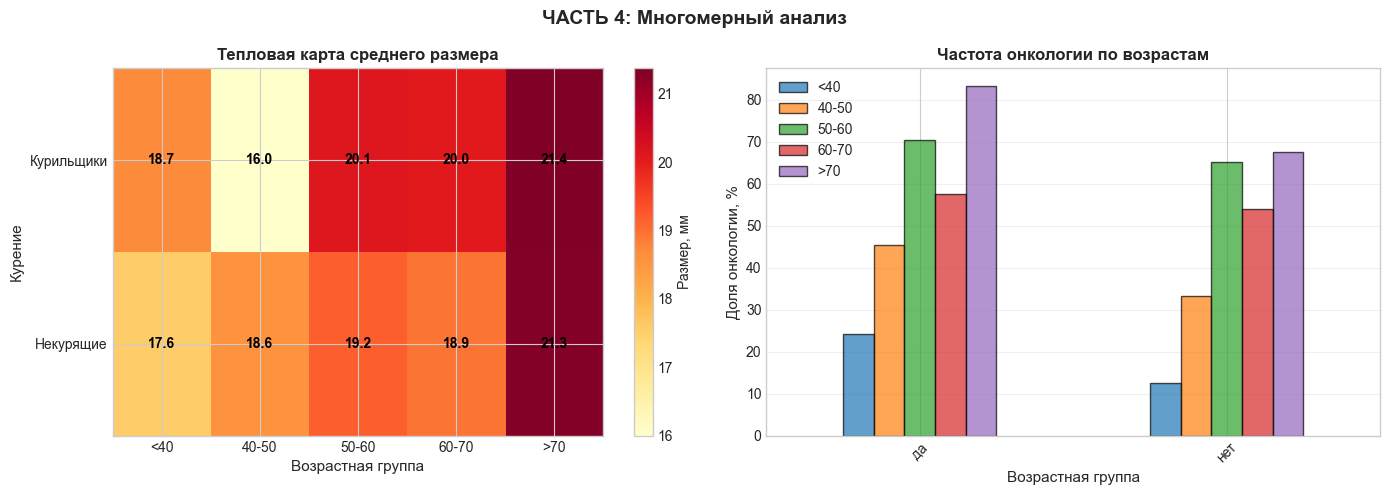


АНАЛИЗ ЗАВЕРШЕН!


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import warnings

from part1_prevalence import analyze_prevalence
from part2_tumor_size import analyze_tumor_size
from part3_odds_ratio import analyze_odds_ratio
from part4_interaction import analyze_interaction

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

def main():
    script_dir = os.path.dirname(os.path.abspath("main.ipynb"))
    data_file = os.path.join(script_dir, 'Data_exam_st.xlsx')
    
    print("=" * 70)
    print("ЗАГРУЗКА ДАННЫХ...")
    print("=" * 70)
    
    try:
        df = pd.read_excel(data_file, header=1)
        print(f"Файл успешно загружен!")
        print(f"Всего записей: {len(df)}")
        df.columns = df.columns.str.strip()
        
        print(f"📑 Столбцов: {len(df.columns)}")
    except Exception as e:
        print(f"Ошибка: {e}")
        return

    print("\nДанные готовы к анализу")
    print("-" * 70)

    # === ЗАПУСК АНАЛИЗА ===
    
    print("\nЧАСТЬ 1: Доля курильщиков")
    print("-" * 70)
    analyze_prevalence(df)
    plt.close('all')

    print("\nЧАСТЬ 2: Размер очага")
    print("-" * 70)
    analyze_tumor_size(df)
    plt.close('all')

    print("\nЧАСТЬ 3: Отношение шансов (OR)")
    print("-" * 70)
    analyze_odds_ratio(df)
    plt.close('all')

    print("\n🔬 ЧАСТЬ 4: Взаимодействие с возрастом")
    print("-" * 70)
    analyze_interaction(df)
    
    print("\n" + "=" * 70)
    print("АНАЛИЗ ЗАВЕРШЕН!")
    print("=" * 70)

if __name__ == "__main__":
    main()